In [2]:
import numpy as np                  #Importing required libraries
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

In [3]:
inputfile =r"/content/song_with_2piccolo.wav"  #this was path to input audio file in my pc.
inputwaveform , sr = librosa.load(inputfile, sr=None) #inputwaveform is form with the help of input signal and sr here is sampling rate.


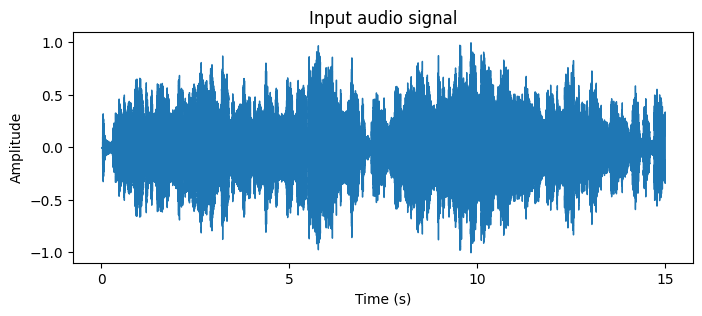

In [4]:
# Time-domain waveform of input audio signal. It is plotted to compare time domain waveform of input file with filtered audio file which will suggest changes in signal.
plt.figure(figsize=(8, 3)) #size of figure formed of time domain waveform
librosa.display.waveshow(inputwaveform, sr=sr)
plt.title('Input audio signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

In [5]:
freqanal = librosa.stft(inputwaveform)  #Here librosa is used to find short time fourier transform  of input wave which is used to find spectrogram
S_db = librosa.amplitude_to_db(np.abs(freqanal), ref=np.max) #for converting amplitude values of spectrogram to decibels


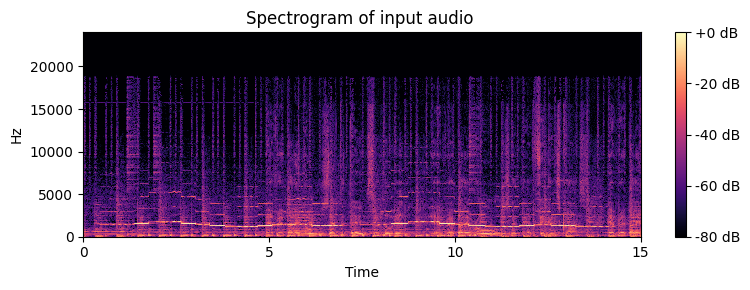

In [6]:
plt.figure(figsize=(8, 3))#size of spectrogram plot
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma') #function for getting spectrogram plot of audio
plt.colorbar(format="%+2.0f dB") #for adding colour scale bar beside graph
plt.title("Spectrogram of input audio ") #title with which plot is displayed
plt.tight_layout()
plt.show()

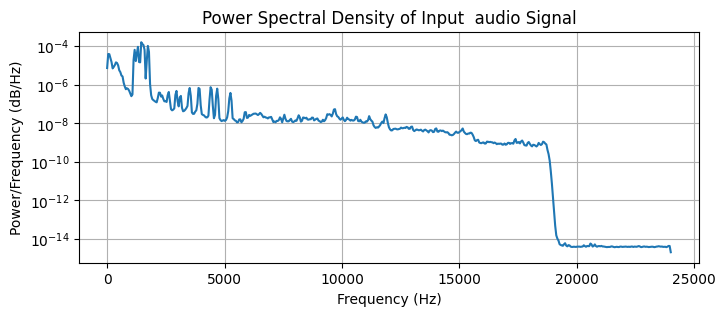

In [7]:
from scipy.signal import  welch #Importing welch function from module which is used to calculate power spectral density.

# Power Spectral Density (PSD)
freq, inputpowden = welch(inputwaveform, fs=sr, nperseg=1024) #Using welch function to calculate power spectral density of input signal

plt.figure(figsize=(8,3)) #size of plot
plt.semilogy(freq, inputpowden) #Plotting spectral density using semi logarithmic scale
plt.title('Power Spectral Density of Input  audio Signal') #Title of plot
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid()
plt.show()


In [8]:
from scipy.signal import butter, freqz, tf2zpk #importing functions to design butterworth filter analyse its frequency response and get zeros , poles and gain.


# Design a buttherworth stop band filter
lowfreq = 1000 # lower limit of stop band frequency
highfreq = 9000  # higher limit of stop band frequency

num , den = butter(N=11, Wn=[lowfreq, highfreq], btype='bandstop', fs=sr) #function taking all inputs and returns numerator = numand denominator = den of filter's transfer function


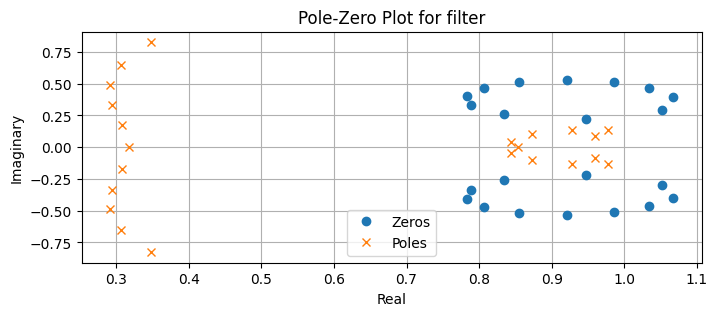

In [9]:
# Pole-Zero Plot of filter
zero, pole , k = tf2zpk(num , den) #here k means gain (amplification of input signal). Getting k , zero and pole for filter transfer function
plt.figure(figsize=(8, 3)) #size of plot
plt.plot(np.real(zero), np.imag(zero), 'o', label='Zeros')
plt.plot(np.real(pole), np.imag(pole), 'x', label='Poles')
plt.title('Pole-Zero Plot for filter') #title of plot
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.grid()
plt.legend()
plt.show()

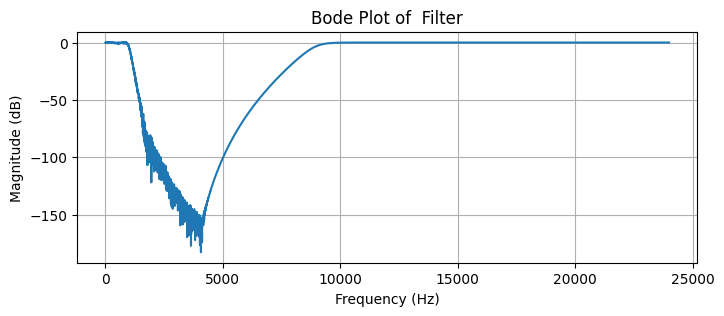

In [11]:
# Bode Plot (Frequency Response) of filter
w, h = freqz(num, den, worN=8000, fs=sr)
plt.figure(figsize=(8 , 3)) #size of plot
plt.plot(w, 20 * np.log10(np.abs(h)))
plt.title('Bode Plot of  Filter') #title of plot
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid()
plt.show()

In [17]:
from scipy.signal import freqz #To prove that in pass band region gain is almost 0 dB this is what I have done
import numpy as np #importing function that computes frequency response from its num and den

# Compute frequency response
freq , freqresp= freqz(num, den, worN=16000, fs=sr) # Giving frequency response at each frequency

# Focus on 0–1000 Hz region to find gain of that region
passband_near_zero = (w >= 0) & (w <= 1000)

# Getting  the magnitude response in that region
gain_values = np.abs(h[passband_near_zero])

# Printing  numerical min and max gain
print("Passband (0–1000 Hz):")
print("  Min gain =", np.min(gain_values))
print("  Max gain =", np.max(gain_values))
print("  Mean gain =", np.mean(gain_values))



Passband (0–1000 Hz):
  Min gain = 0.6284322329308625
  Max gain = 1.0307214338640034
  Mean gain = 0.9535716677948471


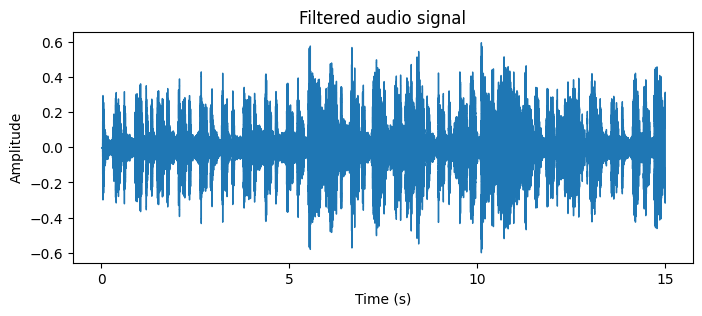

In [19]:
from scipy.signal import lfilter

# Apply the filter
waveformfiltered  = lfilter(num,den, inputwaveform )

# Plot filtered and cleaned audio signal waveform
plt.figure(figsize=(8, 3)) #Again this is size of figure formed for filtered version of audio
librosa.display.waveshow(waveformfiltered, sr=sr)
plt.title('Filtered audio signal') #Title that will be displayed at the top of plot
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

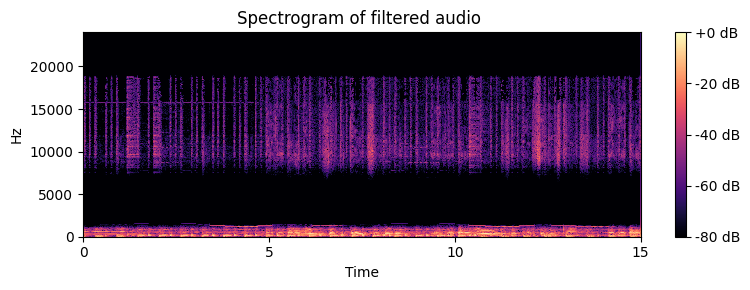

In [20]:
freqanal1 = librosa.stft(waveformfiltered)  #Here librosa is used to find short time fourier transform  of filtered wave which is used to find spectrogram
S_db = librosa.amplitude_to_db(np.abs(freqanal1), ref=np.max) #for converting amplitude values of spectrogram to decibels

plt.figure(figsize=(8, 3))#size of spectrogram plot
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma') #function for getting spectrogram plot of audio
plt.colorbar(format="%+2.0f dB") #for adding colour scale bar beside graph
plt.title("Spectrogram of filtered audio ") #title with which plot is displayed
plt.tight_layout()
plt.show()

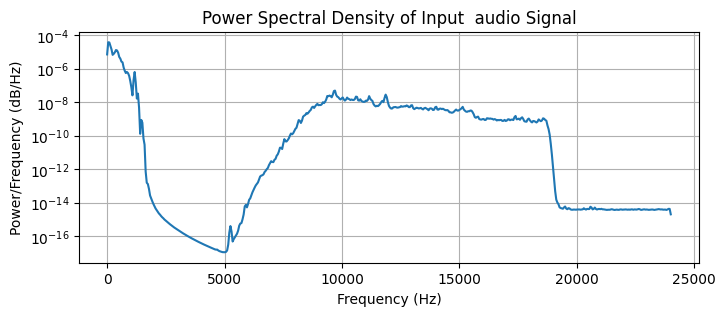

In [22]:
from scipy.signal import  welch #Importing welch function from module which is used to calculate power spectral density.

# Power Spectral Density (PSD)
freq, inputpowden = welch(waveformfiltered, fs=sr, nperseg=1024) #Using welch function to calculate power spectral density of filtered signal

plt.figure(figsize=(8,3)) #size of plot
plt.semilogy(freq, inputpowden) #Plotting spectral density using semi logarithmic scale
plt.title('Power Spectral Density of Input  audio Signal') #Title of plot
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid()
plt.show()

In [23]:
sf.write('restored_audio.wav',waveformfiltered, sr)